#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance 
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [3]:
## Reading the image plaksha_Faculty.jpg
img = cv2.imread("Plaksha_Faculty.jpg")
  
## Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
  
# Applying the face detection method on the grayscale image. 
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(gray_img, 1.05, 4, minSize=(25,25), maxSize=(50,50))
 
# Define the text and font parameters
text = "Faces detected" ## The text you want to write
font = cv2.FONT_HERSHEY_SIMPLEX  ## Font type
font_scale = 1 ## Font scale factor
font_color = (255, 0, 0)  ## Text color in BGR format (here, it's red)
font_thickness = 2  ## Thickness of the text

  
# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    # Use cv2.putText to add the text to the image, Use text, font, font_scale, font_color, font_thickness here
    cv2.putText(img, text=text, org=(500, 30), fontFace=font, fontScale=font_scale, color=font_color, thickness=font_thickness)
    
## Display the image and window title should be "Total number of face detected are #"  
cv2.imshow(f'Total number of face detected are {len(faces_rect)}', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

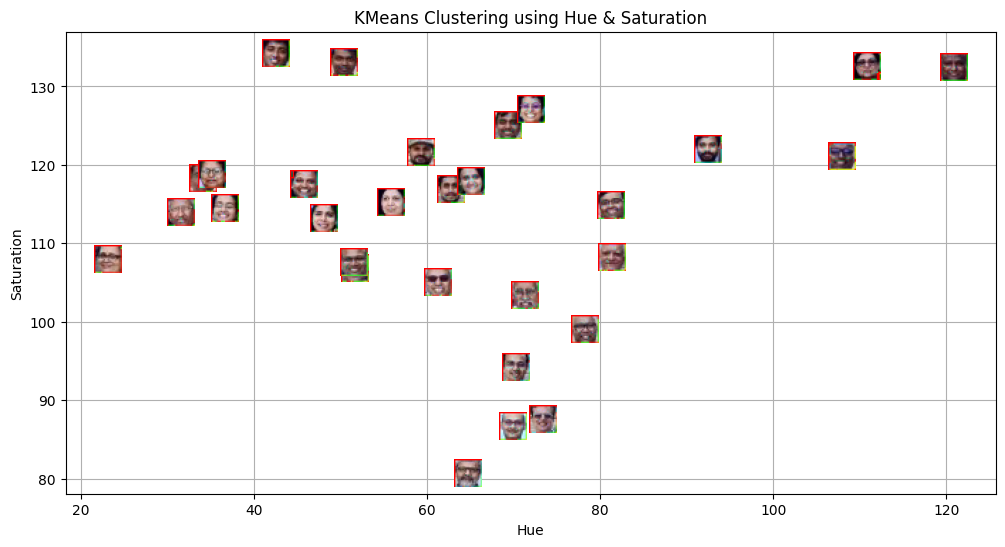

In [4]:

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(init = "random", n_clusters = 2, n_init = 10, random_state = 0)
kmeans.fit(hue_saturation)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    

## Put x label
plt.xlabel("Hue")
## Put y label
plt.ylabel("Saturation")
## Put title
plt.title("KMeans Clustering using Hue & Saturation")
## Put grid
plt.grid()

## show the plot
plt.show()

C:\Users\gsgul\AppData\Local\Temp\ipykernel_34688\3591751060.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


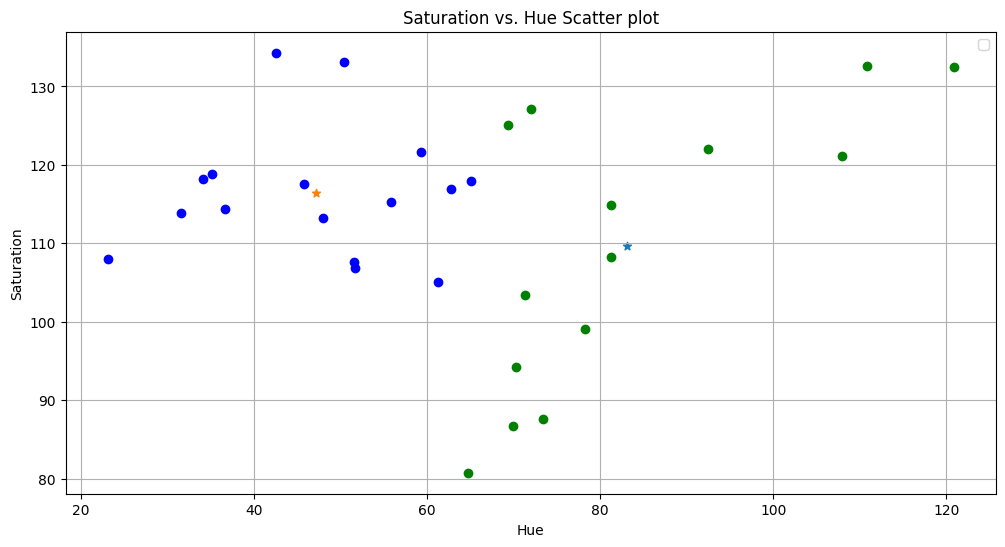

In [ ]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
plt.scatter(cluster_0_points[:,0], cluster_0_points[:,1], color='green')


cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color='blue')

# Calculate and plot centroids
centroid_0 = (np.mean(cluster_0_points[:,0]), np.mean(cluster_0_points[:, 1]))
centroid_1 = (np.mean(cluster_1_points[:,0]), np.mean(cluster_1_points[:, 1]))

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0], centroid_0[1], marker="*")
plt.scatter(centroid_1[0], centroid_1[1], marker="*")

## Put x label
plt.xlabel("Hue")
## Put y label
plt.ylabel("Saturation")
## Put title
plt.title("Saturation vs. Hue Scatter plot")
## Add a legend
plt.legend()
## Add grid
plt.grid()
## Show the plot
plt.show()


In [9]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread("Dr_Shashi_Tharoor.jpg")
template_img_grey = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
# Detect face  in the template image after converting it to gray and store it in template_faces
template_faces = face_cascade.detectMultiScale(template_img_grey, 1.05, 4, minSize=(25,25), maxSize=(250,250))
# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.imshow('Face Detected', template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()      

print(template_faces)

[[ 57  73 219 219]]


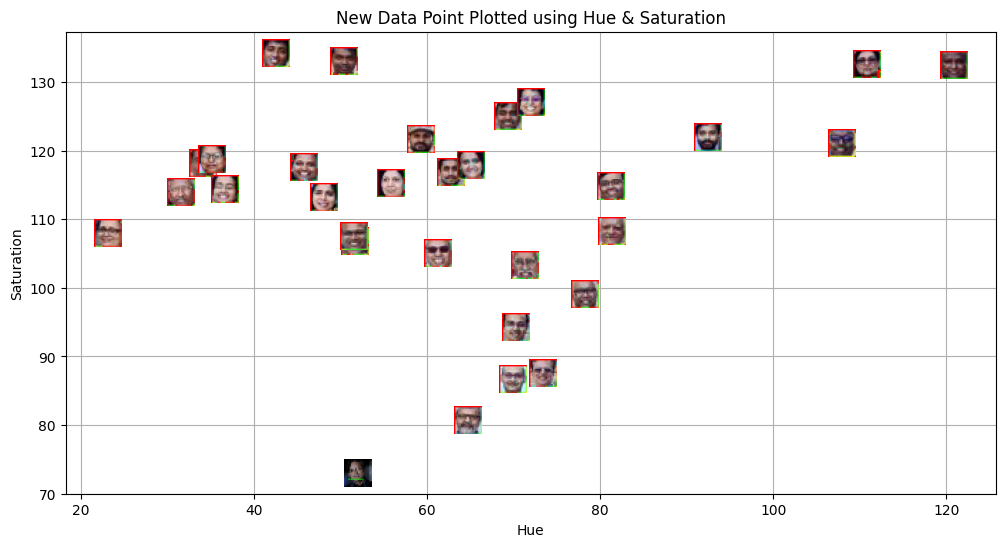

In [16]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img, cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.
face = template_hsv[template_faces[0][1]:template_faces[0][1]+template_faces[0][3], template_faces[0][0]:template_faces[0][0]+template_faces[0][2] ]
template_hue = np.mean(face[:, :, 0])
template_saturation = np.mean(face[:, :, 1])

# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict(np.array([[template_hue, template_saturation]]))[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'
im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)
plt.plot(template_hue, template_saturation, 'o', markersize=5, color=color)

## Put x label
plt.xlabel("Hue")
## Put y label
plt.ylabel("Saturation")
## Put title
plt.title("New Data Point Plotted using Hue & Saturation")
## Add grid
plt.grid()
## show plot
plt.show()

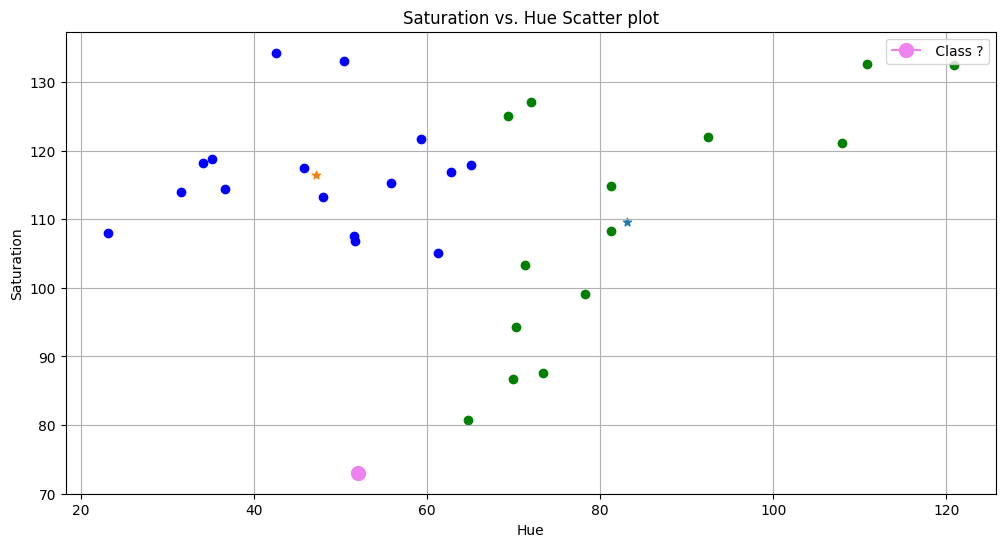

In [17]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:,0], cluster_0_points[:,1], color='green')

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color='blue')

# Calculate and plot centroids for both the clusters
centroid_0 = (np.mean(cluster_0_points[:,0]), np.mean(cluster_0_points[:, 1]))
centroid_1 = (np.mean(cluster_1_points[:,0]), np.mean(cluster_1_points[:, 1]))
plt.scatter(centroid_0[0], centroid_0[1], marker="*")  ## plot for centroid 0
plt.scatter(centroid_1[0], centroid_1[1], marker="*")  ## plot for centroid 1
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=' Class ?' )

## Put x label
plt.xlabel("Hue")
## Put y label
plt.ylabel("Saturation")
## Put title
plt.title("Saturation vs. Hue Scatter plot")
## Add a legend
plt.legend()
## Add grid
plt.grid()
## Show the plot
plt.show()
                                            ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms?
The common distance metrics used in distance-based classification algorithms include: euclidean distance, manhattan distance and chebyshev distance.

#### 2. What are some real-world applications of distance-based classification algorithms? 
Some real world applications are face recognition and image classification, recommendation systems (movies, products, music), spam email detection, medical diagnosis (classifying diseases based on symptoms or measurements), document or text classification, anomaly and fraud detection and pattern recognition in sensor data.

#### 3. Explain various distance metrics. 
1) Euclidean distance: Shortest distance between 2 vectors.
2) Mahalanobis distance: Represents the distance between a point P and a distribution D.
3) Manhattan distance: Distance between two points measured along axes at right angles.
4) Chebyshev distance: It is defined on a vector space where the distance between two vectors is the greatest of their differences along any coordinate dimension.
5) Minkowski distance: A generalized distance metric which can be modified by substituting the value of ‘p’ to calculate the distance  between two points.
6) Cosine distance: Degree of angle between two vectors.
7) Hamming distance: Measures the minimum number of substitutions required to change one string into the other.

#### 4. What is the role of cross validation in model performance? 
Cross validation is used to evaluate how well a model generalizes to unseen data. It works by splitting the dataset into multiple training and validation subsets and averaging the results. It provides a more reliable estimate of model performance by reducing the chances of overfitting to a single data split.It helps ensure that the model generalizes well before testing on the final unseen test data.

#### 5. Explain variance and bias in terms of KNN? 
Thee value of K in KNN decides the tradeoff between bias and variance. A small K (such as 1) makes the model very flexible, resulting in low bias but high variance, meaning it can fit the training data closely but may overfit and be sensitive to noise. A large K creates a smoother decision boundary, leading to high bias but low variance, which makes the model more stable but may cause underfitting by oversimplifying the data patterns.